In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#### load dataset

In [30]:
df = pd.read_csv("C:\\Users\\lenovo\\OneDrive\\Documents\\spam.csv",encoding="latin1")

In [31]:
df 

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [32]:
df.shape

(5572, 5)

In [33]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

print(df.head())
print(df.shape)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)


In [34]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [35]:
df.dropna()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#### class Distribution 

In [36]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [37]:
percentage = df['label'].value_counts(normalize=True) * 100

print(percentage.round(2))

label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


#### Markdown cell
Observation:
The dataset is imbalanced because Ham messages make up approximately 86.59% of the dataset, while Spam messages make up approximately 13.41%. Therefore, accuracy alone should not be used to evaluate the model. Precision, recall and F1-score are also important.

In [38]:
#### Class Distribution Visualization

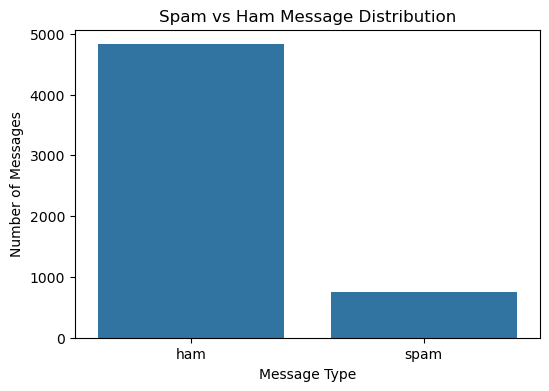

In [39]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

#### Text Preprocessing
The task requires:
Lowercase conversion
Punctuation removal
Stopword removal
Optional stemming/lemmatization
We will use re for cleaning and TfidfVectorizer for stopword removal.

In [40]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [43]:
df = df.copy()

# Clean the messages
df['clean_message'] = df['message'].apply(clean_text)

# Convert labels to numbers
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1})

#### Convert Labels into Numbers

In [46]:

df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

print(df[['label', 'label_num']].head())

  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0


#### Separate Features and Target

In [47]:
# Separate features and target
X = df['clean_message']
y = df['label_num']

print(X.head())
print(y.head())

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in a wkly comp to win fa cup final ...
3          u dun say so early hor u c already then say
4    nah i don t think he goes to usf he lives arou...
Name: clean_message, dtype: object
0    0
1    0
2    1
3    0
4    0
Name: label_num, dtype: int64


#### Train test split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


#### TF-IDF

In [50]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4457, 5000)
Testing TF-IDF shape: (1115, 5000)


### Model 1 – Multinomial Naive Bayes

In [51]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

In [54]:
# Evaluate Naive Bayes

In [55]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Multinomial Naive Bayes")
print("-----------------------")
print("Accuracy :", accuracy_nb)
print("Precision:", precision_nb)
print("Recall   :", recall_nb)
print("F1 Score :", f1_nb)

Multinomial Naive Bayes
-----------------------
Accuracy : 0.9695067264573991
Precision: 0.9914529914529915
Recall   : 0.7785234899328859
F1 Score : 0.8721804511278195


In [58]:
# Navie Bayes Classification Report

In [59]:
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=['Ham', 'Spam']
    )
)

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.78      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [60]:
# Naive Bayes Confusion Matrix


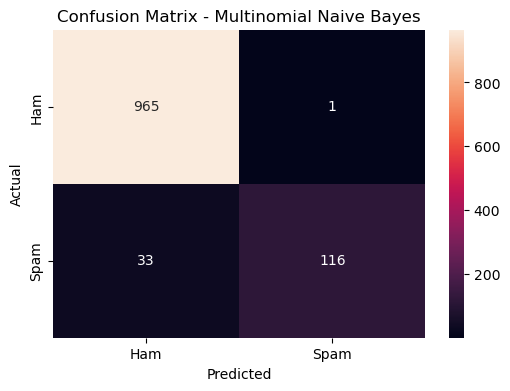

In [61]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Model 2 – Logistic Regression

In [62]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

In [63]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

Logistic Regression
-------------------
Accuracy : 0.9704035874439462
Precision: 0.9915254237288136
Recall   : 0.785234899328859
F1 Score : 0.8764044943820225


In [64]:
# Logistic Regression Classification Report

In [65]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=['Ham', 'Spam']
    )
)

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [66]:
# Logistic Regression Confusion Matrix

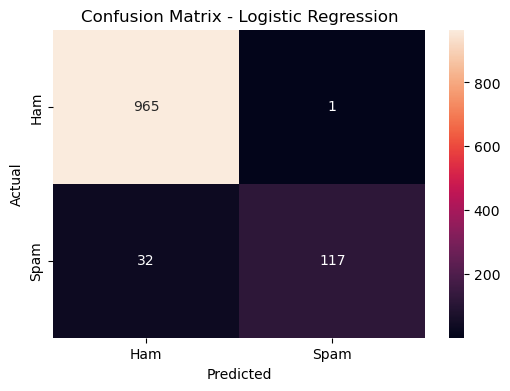

In [67]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Compare Both Models

In [68]:
results = pd.DataFrame({
    'Model': [
        'Multinomial Naive Bayes',
        'Logistic Regression'
    ],
    'Accuracy': [
        accuracy_nb,
        accuracy_lr
    ],
    'Precision': [
        precision_nb,
        precision_lr
    ],
    'Recall': [
        recall_nb,
        recall_lr
    ],
    'F1 Score': [
        f1_nb,
        f1_lr
    ]
})

print(results)

                     Model  Accuracy  Precision    Recall  F1 Score
0  Multinomial Naive Bayes  0.969507   0.991453  0.778523  0.872180
1      Logistic Regression  0.970404   0.991525  0.785235  0.876404


### Why is Recall Important for Spam Detection?




#### Why Recall is Important
Recall measures how many of the actual spam messages were correctly identified by the model.
In spam detection, low recall means that many spam messages are incorrectly classified as legitimate messages (Ham). These missed spam messages may reach the user's inbox and could contain advertisements, scams, phishing attempts or malicious links.
Therefore, recall is particularly important because we want to identify as many actual spam messages as possible.

In [71]:
def predict_spam(message):
    
    cleaned = clean_text(message)
    
    vector = tfidf.transform([cleaned])
    
    prediction = nb_model.predict(vector)[0]
    
    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"




In [72]:
message = "Congratulations! You have won a free lottery ticket!"

print(predict_spam(message))

HAM


#### Bonus – WordCloud for Spam and Ham

In [74]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [78]:

from wordcloud import WordCloud

#### Spam WordCloud

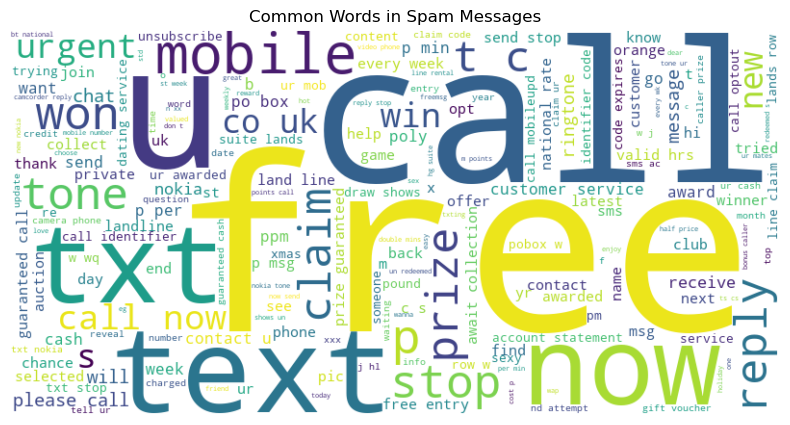

In [80]:
spam_text = " ".join(
    df[df['label'] == 'spam']['clean_message']
)

wordcloud_spam = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud_spam, interpolation='bilinear')

plt.axis('off')
plt.title("Common Words in Spam Messages")

plt.show()

#### Ham WordCloud

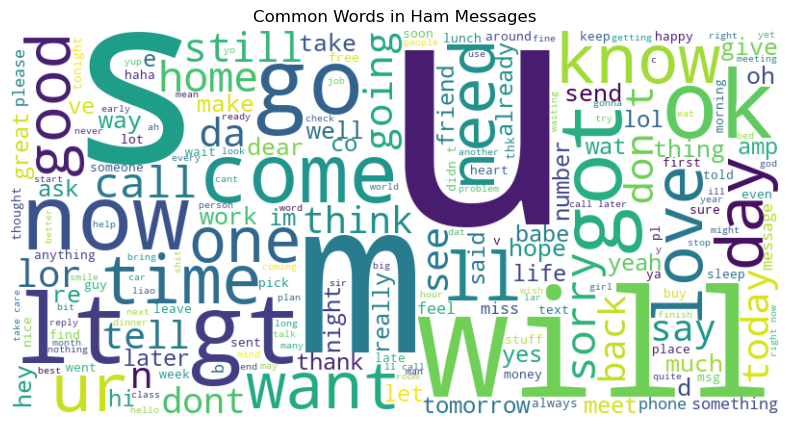

In [82]:
ham_text = " ".join(
    df[df['label'] == 'ham']['clean_message']
)

wordcloud_ham = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud_ham, interpolation='bilinear')

plt.axis('off')
plt.title("Common Words in Ham Messages")

plt.show()

## Final Conclusion

#### Markdown cell
Conclusion
In this project, an NLP-based spam detection system was developed using the SMS Spam Collection dataset containing 5,572 messages. The data was cleaned by removing unnecessary columns and preprocessing the text using lowercase conversion and punctuation removal.
TF-IDF was used to convert text messages into numerical features. Two machine learning algorithms, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated.
Multinomial Naive Bayes achieved approximately 96.95% accuracy, 99.15% precision, 77.85% recall, and 87.22% F1-score. It performed slightly better than Logistic Regression in this experiment.
The results show that machine learning and NLP can effectively classify messages as Spam or Ham. Recall is especially important because incorrectly classifying spam as Ham allows unwanted or potentially harmful messages to reach the user.


#### Best Model: Multinomial Naive Bayes

